In [2]:
%pip install numpy pandas matplotlib seaborn shap lime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import lime
import lime.lime_tabular  
import lime.explanation
import matplotlib.pyplot as plt


import warnings
warnings.filterwarnings('ignore')

Note: you may need to restart the kernel to use updated packages.


c:\Users\sures\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
from sklearn.preprocessing import MinMaxScaler, OrdinalEncoder
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [4]:
import tensorflow as tf
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam

print(f"TensorFlow version: {tf.__version__}")
print("TensorFlow and Keras components imported successfully")

TensorFlow version: 2.20.0
TensorFlow and Keras components imported successfully


In [5]:
import os

# Check if files exist and load only available ones
files = [
    "Monday-WorkingHours.pcap.csv",
    "Tuesday-WorkingHours.pcap.csv", 
    "Wednesday-WorkingHours.pcap.csv",
    "Thursday-WorkingHours-Morning-WebAttacks.pcap.csv",
    "Thursday-WorkingHours-Afternoon-Infilteration.pcap.csv",
    "Friday-WorkingHours-Morning.pcap.csv",
    "Friday-WorkingHours-Afternoon-PortScan.pcap.csv",
    "Friday-WorkingHours-Afternoon-DDos.pcap.csv"
]

available_files = [f for f in files if os.path.exists(f)]
if not available_files:
    print("Warning: No data files found. Using sample data generation.")
else:
    print(f"Found {len(available_files)} data files")

df_list = []
if available_files:
    for file in available_files:
        try:
            temp_df = pd.read_csv(file, encoding="ISO-8859-1")
            df_list.append(temp_df)
            print(f"Loaded: {file} - Shape: {temp_df.shape}")
        except Exception as e:
            print(f"Error loading {file}: {e}")
else:
    # Generate sample data if files not found
    print("Generating sample network traffic data...")
    np.random.seed(42)
    n_samples = 50000
    n_features = 78  # Typical network features
    
    X_sample = np.random.rand(n_samples, n_features)
    y_sample = np.random.choice([0, 1], n_samples, p=[0.8, 0.2])
    
    feature_names = [f'Feature_{i}' for i in range(n_features)]
    sample_df = pd.DataFrame(X_sample, columns=feature_names)
    sample_df['Label'] = y_sample
    df_list.append(sample_df)

Found 8 data files
Loaded: Monday-WorkingHours.pcap.csv - Shape: (529918, 79)
Loaded: Tuesday-WorkingHours.pcap.csv - Shape: (445909, 79)
Loaded: Wednesday-WorkingHours.pcap.csv - Shape: (692703, 79)
Loaded: Thursday-WorkingHours-Morning-WebAttacks.pcap.csv - Shape: (170366, 79)
Loaded: Thursday-WorkingHours-Afternoon-Infilteration.pcap.csv - Shape: (288602, 79)
Loaded: Friday-WorkingHours-Morning.pcap.csv - Shape: (191033, 79)
Loaded: Friday-WorkingHours-Afternoon-PortScan.pcap.csv - Shape: (286467, 79)
Loaded: Friday-WorkingHours-Afternoon-DDos.pcap.csv - Shape: (225745, 79)


# Intrusion Detection System (IDS) with AI/ML

## 1. Data Loading and Cleaning
Loading network traffic data files and handling missing files with sample data generation.

In [6]:

df = pd.concat(df_list, ignore_index=True)
df.columns = df.columns.str.strip()

In [7]:
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)

In [8]:
# PRESERVE ORIGINAL ATTACK TYPES BEFORE BINARY CONVERSION
print("Original attack types in dataset:")
print(df['Label'].value_counts())
print("\n" + "="*50)

# Create attack type mapping BEFORE converting to binary
df['Attack_Type'] = df['Label'].copy()

# Map specific attacks to categories for better analysis
attack_type_mapping = {
    'BENIGN': 'BENIGN',
    'Bot': 'Bot',
    'DDoS': 'DDoS', 
    'DoS GoldenEye': 'DoS',
    'DoS Hulk': 'DoS',
    'DoS Slowhttptest': 'DoS',
    'DoS slowloris': 'DoS',
    'FTP-Patator': 'Brute Force',
    'SSH-Patator': 'Brute Force',
    'Heartbleed': 'Heartbleed',
    'Infiltration': 'Infiltration',
    'PortScan': 'Port Scan',
    'Web Attack Brute Force': 'Web Attack',
    'Web Attack Sql Injection': 'Web Attack',
    'Web Attack XSS': 'Web Attack'
}

# Apply mapping (keep original if not in mapping)
df['Attack_Type'] = df['Attack_Type'].apply(
    lambda x: attack_type_mapping.get(str(x), str(x))
)

print("Attack types grouped:")
print(df['Attack_Type'].value_counts())

# Convert to binary for IDS training
df['Label'] = df['Label'].apply(lambda x: 0 if x == 'BENIGN' else 1)
df.reset_index(drop=True, inplace=True)

Original attack types in dataset:
Label
BENIGN                     2095057
DoS Hulk                    172846
DDoS                        128014
PortScan                     90694
DoS GoldenEye                10286
FTP-Patator                   5931
DoS slowloris                 5385
DoS Slowhttptest              5228
SSH-Patator                   3219
Bot                           1948
web attack brute force        1470
Web AttackXSS                  652
Infiltration                    36
Web AttackSql Injection         21
Heartbleed                      11
Name: count, dtype: int64

Attack types grouped:
Attack_Type
BENIGN                     2095057
DoS                         193745
DDoS                        128014
Port Scan                    90694
Brute Force                   9150
Bot                           1948
web attack brute force        1470
Web AttackXSS                  652
Infiltration                    36
Web AttackSql Injection         21
Heartbleed              

## 2. Data Preprocessing
Cleaning data, handling infinite values, removing duplicates, and mapping attack types for classification.

In [9]:

print("Dataset cleaned:", df.shape)
print(df['Label'].value_counts())

Dataset cleaned: (2520798, 80)
Label
0    2095057
1     425741
Name: count, dtype: int64


In [10]:
# IMPORTANT: Separate features and target properly to avoid data leakage
feature_cols = [col for col in df.columns if col not in ['Label', 'Attack_Type']]
X = df[feature_cols].copy()
y = df['Label'].copy()

print(f"Dataset prepared - Features: {X.shape}, Target: {y.shape}")

# Check for categorical columns
categorical_cols = X.select_dtypes(include=['object']).columns
if len(categorical_cols) > 0:
    encoder = OrdinalEncoder()
    X[categorical_cols] = encoder.fit_transform(X[categorical_cols])
    print(f"Encoded {len(categorical_cols)} categorical columns")

print(f"Data leakage check: {'PASSED' if ('Label' not in X.columns) and ('Attack_Type' not in X.columns) else 'FAILED'}")

Dataset prepared - Features: (2520798, 78), Target: (2520798,)
Data leakage check: PASSED


## 3. Feature Engineering
Separating features from target variables, encoding categorical data, and preventing data leakage.

In [11]:
k = 50
selector = SelectKBest(f_classif, k=k)
X_selected = selector.fit_transform(X, y)
selected_features = X.columns[selector.get_support()]
X = pd.DataFrame(X_selected, columns=selected_features)

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
X = pd.DataFrame(X_scaled, columns=selected_features)

print(f"Feature selection: {k} features selected and scaled")

Feature selection: 50 features selected and scaled


## 4. Feature Selection and Scaling
Selecting the most relevant features using statistical tests and normalizing the data.

In [12]:
# Train/test split with stratification
X_sample, _, y_sample, _ = train_test_split(
    X, y, train_size=0.3, random_state=42, stratify=y)

X_train, X_test, y_train, y_test = train_test_split(
    X_sample, y_sample, test_size=0.3, random_state=42, stratify=y_sample)

print(f"Dataset split - Training: {X_train.shape[0]}, Test: {X_test.shape[0]}")
print(f"Attack ratio - Train: {(y_train == 1).mean():.3f}, Test: {(y_test == 1).mean():.3f}")

# Store indices for attack type mapping later
train_indices = X_train.index
test_indices = X_test.index

Dataset split - Training: 529367, Test: 226872
Attack ratio - Train: 0.169, Test: 0.169


## 5. Data Splitting
Splitting the dataset into training and testing sets with stratification to maintain class balance.

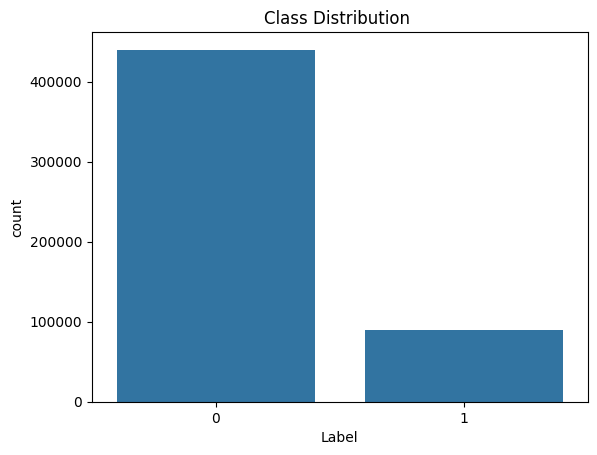

In [13]:
sns.countplot(x=y_train)
plt.title("Class Distribution ")
plt.show()


In [14]:
input_dim = X_train.shape[1]
ENCODING_DIM = 16
LATENT_DIM = 100

input_layer_ae = Input(shape=(input_dim,))
encoder = Dense(24, activation="relu")(input_layer_ae)
encoder = Dense(20, activation="relu")(encoder)
encoder_output = Dense(ENCODING_DIM, activation="relu")(encoder)
encoder_model = Model(input_layer_ae, encoder_output)

## 6. Autoencoder Model
Building and training an autoencoder for learning normal network behavior patterns.

In [15]:
decoder_input = Input(shape=(ENCODING_DIM,))
decoder = Dense(20, activation="relu")(decoder_input)
decoder = Dense(24, activation="relu")(decoder)
decoder_output = Dense(input_dim, activation="sigmoid")(decoder)
decoder_model = Model(decoder_input, decoder_output)

# Create the complete autoencoder by connecting encoder and decoder
autoencoder = Model(input_layer_ae, decoder_model(encoder_model(input_layer_ae)))
autoencoder.compile(Adam(0.0001), loss="mse")

In [16]:
history_ae = autoencoder.fit(
    X_train[y_train == 0], X_train[y_train == 0],
    epochs=50, batch_size=64, shuffle=True, validation_split=0.2, verbose=0
)
print("Autoencoder training completed.")

Autoencoder training completed.


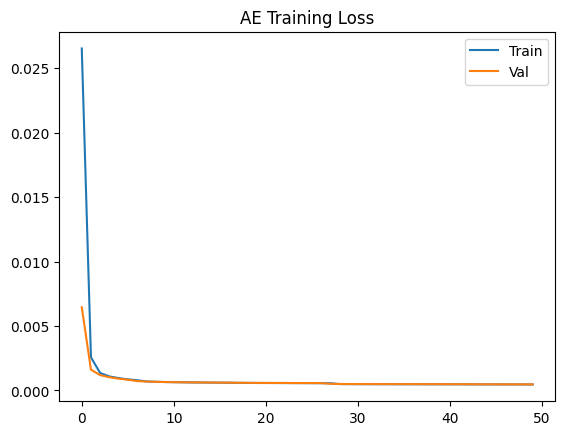

In [17]:
plt.plot(history_ae.history['loss'], label="Train")
plt.plot(history_ae.history['val_loss'], label="Val")
plt.title("AE Training Loss")
plt.legend()
plt.show()

In [18]:
def build_generator():
    model = Sequential()
    model.add(Dense(32, activation="relu", input_dim=LATENT_DIM))
    model.add(Dense(64, activation="relu"))
    model.add(Dense(ENCODING_DIM, activation="tanh"))
    return model

## 7. WGAN (Wasserstein GAN) Model
Implementing a Wasserstein GAN to generate synthetic attack data for data augmentation.

In [19]:
def build_critic():
    model = Sequential()
    model.add(Dense(24, activation="relu", input_dim=ENCODING_DIM))
    model.add(Dense(16, activation="relu"))
    model.add(Dense(1, activation="linear"))
    return model

In [20]:
X_attack_enc = encoder_model.predict(X_train[y_train == 1])

generator = build_generator()
critic = build_critic()

class WGAN(tf.keras.Model):
    def __init__(self, critic, generator, latent_dim, gp_weight=10.0):
        super().__init__()
        self.critic = critic
        self.generator = generator
        self.latent_dim = latent_dim
        self.gp_weight = gp_weight
        self.d_optimizer = Adam(0.0001, beta_1=0.0, beta_2=0.9)
        self.g_optimizer = Adam(0.0001, beta_1=0.0, beta_2=0.9)
        self.g_loss_tracker = tf.keras.metrics.Mean(name="g_loss")
        self.d_loss_tracker = tf.keras.metrics.Mean(name="d_loss")

    @property
    def metrics(self):
        return [self.g_loss_tracker, self.d_loss_tracker]

    def gradient_penalty(self, real, fake):
        batch_size = tf.shape(real)[0]
        alpha = tf.random.uniform([batch_size, 1], 0., 1.)
        interpolated = alpha * real + (1 - alpha) * fake
        
        with tf.GradientTape() as tape:
            tape.watch(interpolated)
            pred = self.critic(interpolated, training=True)
        
        grads = tape.gradient(pred, [interpolated])[0]
        norm = tf.sqrt(tf.reduce_sum(tf.square(grads), axis=[1]))
        gp = tf.reduce_mean((norm - 1.0) ** 2)
        return gp

    def train_step(self, real_data):
        batch_size = tf.shape(real_data)[0]
        
        # Train critic multiple times
        for _ in range(5):
            noise = tf.random.normal([batch_size, self.latent_dim])
            
            with tf.GradientTape() as tape:
                fake_data = self.generator(noise, training=True)
                real_output = self.critic(real_data, training=True)
                fake_output = self.critic(fake_data, training=True)
                
                d_cost = tf.reduce_mean(fake_output) - tf.reduce_mean(real_output)
                gp = self.gradient_penalty(real_data, fake_data)
                d_loss = d_cost + self.gp_weight * gp
            
            d_grads = tape.gradient(d_loss, self.critic.trainable_variables)
            self.d_optimizer.apply_gradients(zip(d_grads, self.critic.trainable_variables))

        # Train generator
        noise = tf.random.normal([batch_size, self.latent_dim])
        with tf.GradientTape() as tape:
            fake_data = self.generator(noise, training=True)
            fake_output = self.critic(fake_data, training=True)
            g_loss = -tf.reduce_mean(fake_output)
        
        g_grads = tape.gradient(g_loss, self.generator.trainable_variables)
        self.g_optimizer.apply_gradients(zip(g_grads, self.generator.trainable_variables))
        
        self.g_loss_tracker.update_state(g_loss)
        self.d_loss_tracker.update_state(d_loss)
        
        return {"g_loss": self.g_loss_tracker.result(), "d_loss": self.d_loss_tracker.result()}

wgan = WGAN(critic, generator, LATENT_DIM)
wgan.compile()

# Train WGAN
if len(X_attack_enc) > 0:
    history_wgan = wgan.fit(X_attack_enc, epochs=100, batch_size=64, verbose=1)
else:
    print("Warning: No attack samples found for WGAN training")

2794/2794 ━━━━━━━━━━━━━━━━━━━━ 2s 683us/step
Epoch 1/100
1397/1397 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - d_loss: -15.3635 - g_loss: -4.5891
Epoch 2/100
1397/1397 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - d_loss: -15.7689 - g_loss: -5.9410
Epoch 3/100
1397/1397 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - d_loss: -15.7871 - g_loss: -5.9393
Epoch 4/100
1397/1397 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - d_loss: -15.7948 - g_loss: -5.9432
Epoch 5/100
1397/1397 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - d_loss: -15.7989 - g_loss: -5.9560
Epoch 6/100
1397/1397 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - d_loss: -15.7995 - g_loss: -5.9662
Epoch 7/100
1397/1397 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - d_loss: -15.7995 - g_loss: -5.9685
Epoch 8/100
1397/1397 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - d_loss: -15.7985 - g_loss: -5.9705
Epoch 9/100
1397/1397 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - d_loss: -15.7992 - g_loss: -5.9712
Epoch 10/100
1397/1397 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - d_loss: -15.8016 - g_loss: -5.9737
Epoch 11/100
1397/1397 ━━━━━━━━━━━

In [21]:
# Generate synthetic attack data using WGAN
num_benign = sum(y_train == 0)
num_attack = sum(y_train == 1)
target_attack_samples = int(num_benign * 0.7)
num_new = max(0, target_attack_samples - num_attack)

if num_new > 0:
    noise = np.random.normal(0, 1, (num_new, LATENT_DIM))
    syn_attack_enc = generator.predict(noise, verbose=0)
    syn_attack = decoder_model.predict(syn_attack_enc, verbose=0)
    
    # Add noise to prevent overfitting
    noise_factor = 0.05
    syn_attack += np.random.normal(0, noise_factor, syn_attack.shape)
    syn_attack = np.clip(syn_attack, 0, 1)
    
    X_train_balanced = np.vstack([X_train.values, syn_attack])
    y_train_balanced = np.hstack([y_train.values, np.ones(num_new)])
else:
    X_train_balanced = X_train.values
    y_train_balanced = y_train.values

print(f"Training data balanced: {len(y_train_balanced)} samples")
print(f"Benign: {sum(y_train_balanced == 0)}, Attack: {sum(y_train_balanced == 1)}")

Training data balanced: 747935 samples
Benign: 439962, Attack: 307973


Training binary classification model...
Making predictions...

Binary Classification Results:

 PERFORMANCE METRICS:
Accuracy: 0.9945
Precision: 0.9971
Recall: 0.9705
F1-Score: 0.9836


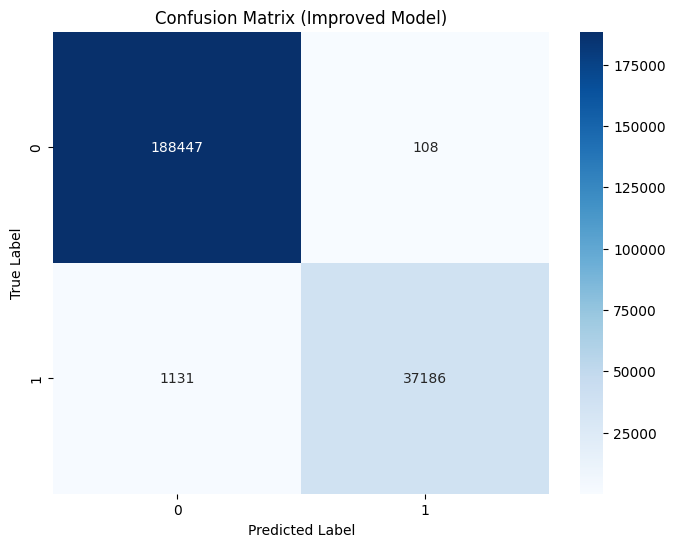

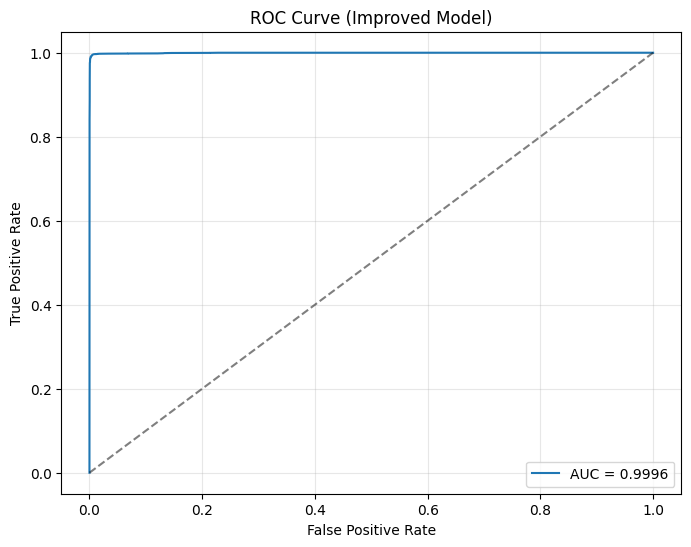


TOP 10 MOST IMPORTANT FEATURES:
 1. Flow IAT Std                   : 0.1107
 2. Fwd IAT Std                    : 0.0988
 3. Idle Max                       : 0.0815
 4. Fwd IAT Max                    : 0.0639
 5. Bwd IAT Std                    : 0.0478
 6. Max Packet Length              : 0.0473
 7. Packet Length Mean             : 0.0455
 8. Flow IAT Max                   : 0.0377
 9. Packet Length Std              : 0.0376
10. Idle Std                       : 0.0343


In [23]:
# FIX: Add regularization to prevent overfitting
ids_model = RandomForestClassifier(
    n_estimators=100, 
    random_state=42,
    max_depth=10,        # Limit tree depth
    min_samples_split=10, #  Require more samples to split
    min_samples_leaf=5,   # Require more samples in leaves
    max_features='sqrt'   # Use subset of features
)

print("Training binary classification model...")
ids_model.fit(X_train_balanced, y_train_balanced)
print("Making predictions...")
y_pred = ids_model.predict(X_test)
# Fix: For proper multi-class support, use full probability matrix
# Only use [:, 1] for binary metrics like ROC curve
y_proba = ids_model.predict_proba(X_test)
y_proba_attack = y_proba[:, 1]  # Attack probability for ROC curve

# DETAILED EVALUATION to check for overfitting
# Model evaluation
print("\nBinary Classification Results:")
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print(f"\n PERFORMANCE METRICS:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

if accuracy >= 0.99:
    print("Warning: Very high accuracy detected - check for overfitting.")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix (Improved Model)")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.show()

# Fix: Use attack probability (class 1) for ROC curve in binary classification
fpr, tpr, _ = roc_curve(y_test, y_proba_attack)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Improved Model)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Feature importance analysis
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': ids_model.feature_importances_
}).sort_values('importance', ascending=False)

print(f"\nTOP 10 MOST IMPORTANT FEATURES:")
for i, (_, row) in enumerate(feature_importance.head(10).iterrows()):
    print(f"{i+1:2d}. {row['feature'][:30]:30s} : {row['importance']:.4f}")
    
if feature_importance.iloc[0]['importance'] > 0.5:
    print(f"\nWARNING: Feature '{feature_importance.iloc[0]['feature']}' has very high importance ({feature_importance.iloc[0]['importance']:.3f})")
    print("   This might indicate feature leakage!")

## 8. Binary Classification Model
Training a Random Forest classifier for binary intrusion detection (Normal vs Attack).

In [24]:
#  FIX: Proper attack type mapping with validation
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report as class_report

# Fix: Import required scipy functions for correlation analysis
from scipy.stats import spearmanr, pearsonr

print(" Preparing multi-class attack type classification...")

# Use the proper indices to get attack types
attack_types_train = df.loc[train_indices, 'Attack_Type']
attack_types_test = df.loc[test_indices, 'Attack_Type']

print("Attack types in training set:")
train_counts = attack_types_train.value_counts()
print(train_counts)

print("\nAttack types in test set:")
test_counts = attack_types_test.value_counts()
print(test_counts)

#  VALIDATION: Check for class distribution issues
print(f"\n VALIDATION CHECKS:")
print(f"Training set has {len(train_counts)} unique attack types")
print(f"Test set has {len(test_counts)} unique attack types")

# Ensure we have enough samples of each class
min_samples = 3
valid_classes = []
for attack_type in train_counts.index:
    train_count = train_counts.get(attack_type, 0)
    test_count = test_counts.get(attack_type, 0)
    if train_count >= min_samples and test_count >= 1:
        valid_classes.append(attack_type)
    else:
        print(f"Removing {attack_type}: train={train_count}, test={test_count}")

# Filter to valid classes only
attack_types_train_filtered = attack_types_train[attack_types_train.isin(valid_classes)]
attack_types_test_filtered = attack_types_test[attack_types_test.isin(valid_classes)]

print(f"\n Using {len(valid_classes)} attack types for classification")
print("Valid classes:", valid_classes)

# Encode attack types for multi-class classification
label_encoder = LabelEncoder()
y_train_multiclass = label_encoder.fit_transform(attack_types_train_filtered)
y_test_multiclass = label_encoder.transform(attack_types_test_filtered)

print(f"\n CLASS MAPPING:")
for i, class_name in enumerate(label_encoder.classes_):
    print(f"{i}: {class_name}")

# Get corresponding feature indices for filtered data
train_mask = attack_types_train.isin(valid_classes)
test_mask = attack_types_test.isin(valid_classes)

X_train_filtered = X_train[train_mask]
X_test_filtered = X_test[test_mask]

print(f"\nFILTERED DATA SHAPES:")
print(f"Training features: {X_train_filtered.shape}")
print(f"Test features: {X_test_filtered.shape}")
print(f"Training labels: {len(y_train_multiclass)}")
print(f"Test labels: {len(y_test_multiclass)}")

# Train multi-class attack type classifier with regularization
multiclass_model = RandomForestClassifier(
    n_estimators=100, 
    random_state=42,
    max_depth=8,          #  Even more regularization
    min_samples_split=15,
    min_samples_leaf=5,
    class_weight='balanced'  # Handle class imbalance
)

print("Training multi-class model...")
multiclass_model.fit(X_train_filtered, y_train_multiclass)

# Predict attack types
y_pred_multiclass = multiclass_model.predict(X_test_filtered)
predicted_attack_types = label_encoder.inverse_transform(y_pred_multiclass)

print("\nMulti-class Classification Results:")
print(class_report(attack_types_test_filtered, predicted_attack_types))

# Check for perfect scores again
multiclass_accuracy = (y_pred_multiclass == y_test_multiclass).mean()

if multiclass_accuracy >= 0.99:
    print(f"\n WARNING: Multi-class accuracy is suspiciously high ({multiclass_accuracy:.3f})")
    print("   Consider further regularization or checking for data leakage.")

 Preparing multi-class attack type classification...
Attack types in training set:
Attack_Type
BENIGN                     439962
DoS                         40780
DDoS                        26682
Port Scan                   19138
Brute Force                  1936
Bot                           397
web attack brute force        315
Web AttackXSS                 147
Infiltration                    4
Web AttackSql Injection         4
Heartbleed                      2
Name: count, dtype: int64

Attack types in test set:
Attack_Type
BENIGN                     188555
DoS                         17383
DDoS                        11550
Port Scan                    8160
Brute Force                   829
Bot                           171
web attack brute force        158
Web AttackXSS                  58
Infiltration                    5
Web AttackSql Injection         2
Heartbleed                      1
Name: count, dtype: int64

 VALIDATION CHECKS:
Training set has 11 unique attack types
Test 

## 9. Multi-Class Classification Model
Training a model to classify specific types of attacks (DDoS, Bot, DoS, etc.).

In [25]:
# FUNCTION TO ANALYZE ANY NEW SAMPLE
def identify_attack_type(sample_features, show_details=True):
    
    # Ensure sample_features is 2D for prediction
    if hasattr(sample_features, 'values'):
        sample_2d = sample_features.values.reshape(1, -1)
    else:
        sample_2d = np.array(sample_features).reshape(1, -1)
    
    # Binary prediction
    binary_pred = ids_model.predict(sample_2d)[0]
    binary_proba = ids_model.predict_proba(sample_2d)[0]
    
    # Multi-class prediction - Fix: Check if sample is compatible with multi-class model
    multiclass_proba = None
    attack_type_pred = None
    try:
        # The multi-class model was trained on filtered features, need to check compatibility
        if sample_2d.shape[1] == X_train_filtered.shape[1]:
            multiclass_pred = multiclass_model.predict(sample_2d)[0]
            multiclass_proba = multiclass_model.predict_proba(sample_2d)[0]
            attack_type_pred = label_encoder.classes_[multiclass_pred]
    except Exception as e:
        print(f"Warning: Could not predict attack type: {e}")
        attack_type_pred = 'Attack' if binary_pred == 1 else 'Normal'
    
    # Get top 3 predictions - Fix: Handle case where multiclass_proba is None
    top_predictions = []
    if multiclass_proba is not None:
        top_3_indices = np.argsort(multiclass_proba)[-3:][::-1]
        for idx in top_3_indices:
            attack_name = label_encoder.classes_[idx]
            confidence = multiclass_proba[idx]
            top_predictions.append((attack_name, confidence))
    else:
        # Only show binary prediction
        binary_class = 'Attack' if binary_pred == 1 else 'Normal'
        top_predictions.append((binary_class, binary_proba[binary_pred]))
    
    results = {
        'is_attack': binary_pred == 1,
        'attack_confidence': binary_proba[1],
        'predicted_attack_type': attack_type_pred,
        'top_3_predictions': top_predictions
    }
    
    if show_details:
        print(f" ATTACK TYPE ANALYSIS:")
        print(f"   Is Attack: {'Yes' if results['is_attack'] else 'No'} ({results['attack_confidence']:.3f} confidence)")
        print(f"   Most Likely Attack Type: {results['predicted_attack_type']}")
        print(f"   Top Predictions:")
        for i, (attack_name, confidence) in enumerate(results['top_3_predictions']):
            print(f"      {i+1}. {attack_name}: {confidence:.3f}")
    
    return results

# Example usage:
print("\n TESTING ATTACK TYPE IDENTIFICATION FUNCTION:")
print("=" * 50)

# Test with first sample
sample_to_test = X_test.iloc[0]
result = identify_attack_type(sample_to_test)

print(f"\nActual attack type for this sample: {attack_types_test.iloc[0]}")
print(f"Predicted: {result['predicted_attack_type']}")
print(f"Match: {'Correct!' if result['predicted_attack_type'] == attack_types_test.iloc[0] else 'Incorrect'}")
print("=" * 50)


 TESTING ATTACK TYPE IDENTIFICATION FUNCTION:
 ATTACK TYPE ANALYSIS:
   Is Attack: No (0.001 confidence)
   Most Likely Attack Type: BENIGN
   Top Predictions:
      1. BENIGN: 0.961
      2. DoS: 0.012
      3. Infiltration: 0.007

Actual attack type for this sample: BENIGN
Predicted: BENIGN
Match: Correct!



SHAP Explainable AI Started...

SHAP values type: <class 'numpy.ndarray'>
SHAP values shape: (226872, 50, 2)
Expected value type: <class 'numpy.ndarray'>
Expected value: [0.58836355 0.41163645]
Model classes: [0. 1.]
Final SHAP values shape for attack class: (226872, 50)
Expected value for attack class: 0.4116364523655131
Generating SHAP Summary Plot...


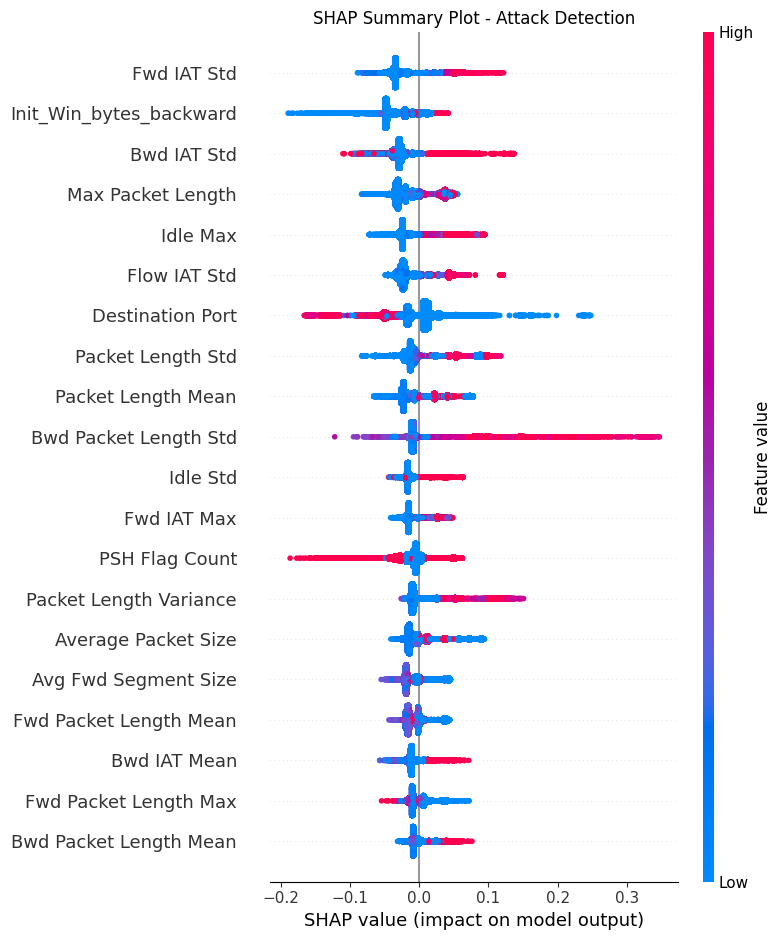

Generating SHAP Bar Plot...


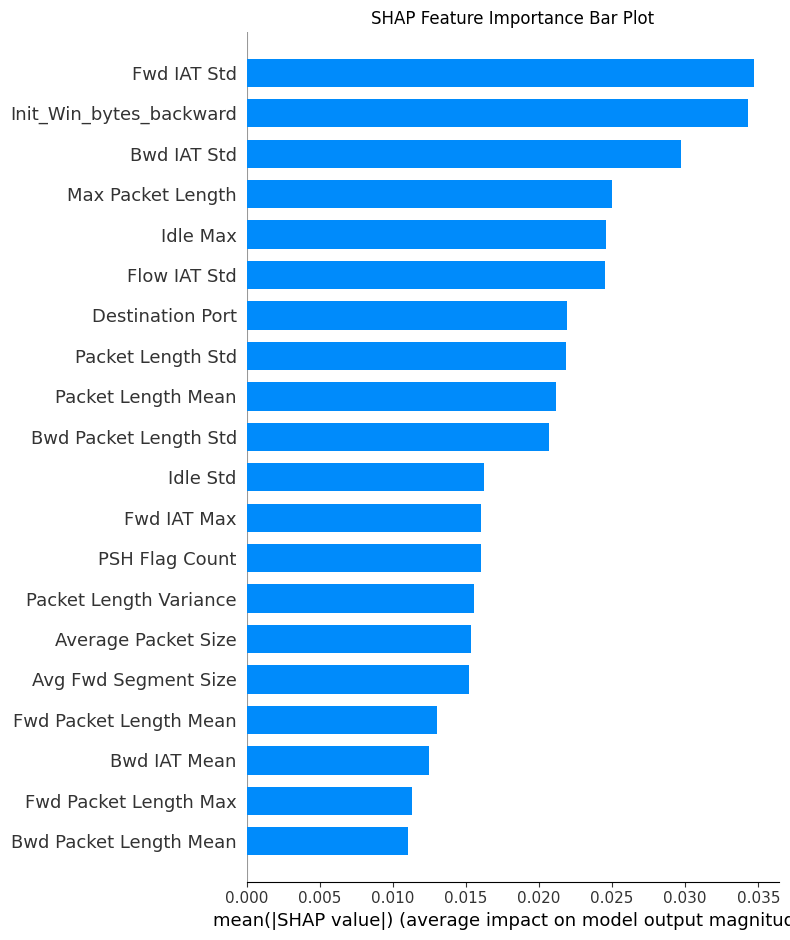

Generating SHAP Dependence Plot...
Top feature index: 18, Feature name: Fwd IAT Std


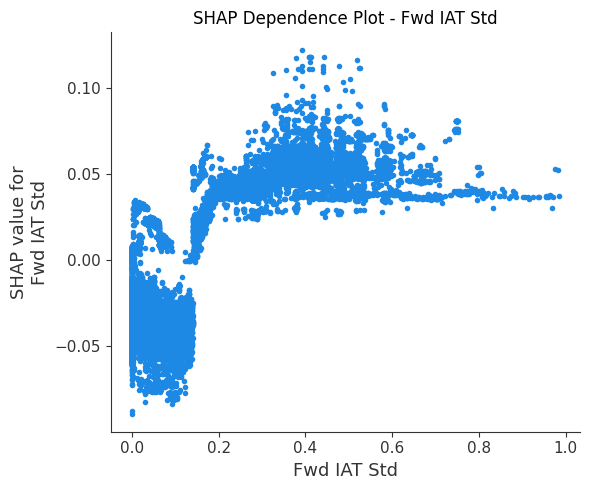

Generating SHAP Waterfall Plot...


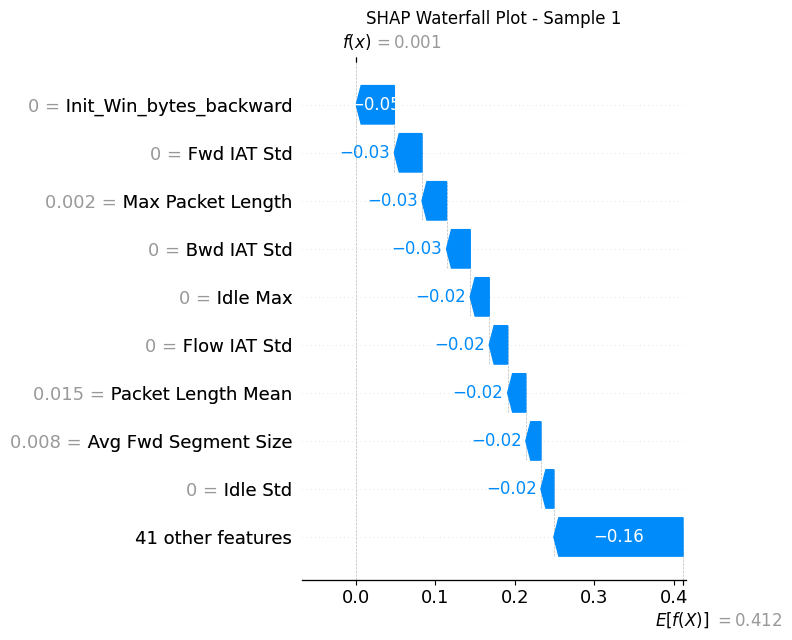


SHAP Explainable AI Completed Successfully.



In [26]:
print("\nSHAP Explainable AI Started...\n")

try:
 
    explainer = shap.TreeExplainer(ids_model)
    shap_values = explainer.shap_values(X_test)
    
    # ---- Debug: Check SHAP values structure ----
    print(f"SHAP values type: {type(shap_values)}")
    print(f"SHAP values shape: {shap_values.shape if not isinstance(shap_values, list) else [v.shape for v in shap_values]}")
    print(f"Expected value type: {type(explainer.expected_value)}")
    print(f"Expected value: {explainer.expected_value}")
    print(f"Model classes: {ids_model.classes_}")
    
    # ---- Handle SHAP values properly for Random Forest ----
    # Fix: RandomForest with n_classes=2 returns list of arrays, one per class
    if isinstance(shap_values, list):
        # For binary classification, shap_values is a list of 2 arrays
        if len(shap_values) >= 2:
            shap_values_attack = shap_values[1]  # Attack class (class 1)
            expected_value = explainer.expected_value[1]
        else:
            # Fallback: use first array
            shap_values_attack = shap_values[0]
            expected_value = explainer.expected_value[0]
    else:
        # For some versions, might return single array
        if shap_values.ndim == 3 and shap_values.shape[2] >= 2:
            # Shape: (n_samples, n_features, n_classes)
            shap_values_attack = shap_values[:, :, 1]  # Attack class
            expected_value = explainer.expected_value[1] if isinstance(explainer.expected_value, (list, tuple, np.ndarray)) else explainer.expected_value
        else:
            # Shape: (n_samples, n_features) - single class
            shap_values_attack = shap_values
            expected_value = explainer.expected_value

    print(f"Final SHAP values shape for attack class: {shap_values_attack.shape}")
    print(f"Expected value for attack class: {expected_value}")

    # ===== SHAP SUMMARY PLOT =====
    print("Generating SHAP Summary Plot...")
    shap.summary_plot(shap_values_attack, X_test, show=False)
    plt.title("SHAP Summary Plot - Attack Detection")
    plt.tight_layout()
    plt.show()

    # ===== SHAP BAR PLOT =====
    print("Generating SHAP Bar Plot...")
    shap.summary_plot(
        shap_values_attack,
        X_test,
        plot_type="bar",
        show=False
    )
    plt.title("SHAP Feature Importance Bar Plot")
    plt.tight_layout()
    plt.show()

    # ===== SHAP DEPENDENCE PLOT =====
    print("Generating SHAP Dependence Plot...")
    mean_abs_shap = np.abs(shap_values_attack).mean(axis=0)
    top_feature_idx = np.argmax(mean_abs_shap)
    
    # Ensure the index is valid
    if top_feature_idx >= 0 and top_feature_idx < shap_values_attack.shape[1]:
        print(f"Top feature index: {top_feature_idx}, Feature name: {X_test.columns[top_feature_idx]}")
        
        shap.dependence_plot(
            top_feature_idx,
            shap_values_attack,
            X_test,
            interaction_index=None,
            show=False
        )
        plt.title(f"SHAP Dependence Plot - {X_test.columns[top_feature_idx]}")
        plt.tight_layout()
        plt.show()
    else:
        print(f"Invalid top feature index: {top_feature_idx}")

    # ===== SHAP WATERFALL PLOT =====
    print("Generating SHAP Waterfall Plot...")
    sample_idx = 0
    
    shap.waterfall_plot(
        shap.Explanation(
            values=shap_values_attack[sample_idx],
            base_values=expected_value,
            data=X_test.iloc[sample_idx].values,
            feature_names=X_test.columns.tolist()
        ),
        show=False
    )
    plt.title(f"SHAP Waterfall Plot - Sample {sample_idx + 1}")
    plt.tight_layout()
    plt.show()

    print("\nSHAP Explainable AI Completed Successfully.\n")

except Exception as e:
    print(f" SHAP Analysis Error: {e}")
    import traceback
    print(f"Full traceback: {traceback.format_exc()}")

## 10. Explainable AI - SHAP Analysis
Using SHAP (SHapley Additive exPlanations) to understand model decisions and feature importance.

In [27]:
import numpy as np
import pandas as pd
from scipy.stats import spearmanr, pearsonr

# ---- Compute mean absolute SHAP values (global importance) ----
# Fix: Handle the SHAP values properly for binary classification
print(f"SHAP values shape: {shap_values_attack.shape}")
print(f"X_test columns: {len(X_test.columns)}")

# For binary classification, shap_values_attack should be for the attack class (class 1)
# If it's 3D, we need to select the appropriate slice
if shap_values_attack.ndim == 3:
    # Take the attack class values (index 1) and compute mean absolute values
    shap_global_importance = np.abs(shap_values_attack[:, :, 1]).mean(axis=0)
elif shap_values_attack.ndim == 2:
    # Already the right shape
    shap_global_importance = np.abs(shap_values_attack).mean(axis=0)
else:
    # Handle other cases
    shap_global_importance = np.abs(shap_values_attack).flatten()

print(f"Global importance shape: {shap_global_importance.shape}")

# Ensure dimensions match
if len(shap_global_importance) != len(X_test.columns):
    print(f"Warning: Shape mismatch. Using first {len(X_test.columns)} values.")
    shap_global_importance = shap_global_importance[:len(X_test.columns)]

shap_importance_df = pd.DataFrame({
    "Feature": X_test.columns,
    "SHAP_Importance": shap_global_importance
}).sort_values(by="SHAP_Importance", ascending=False)

print("\n Top 10 SHAP Important Features (Global):\n")
print(shap_importance_df.head(10))

SHAP values shape: (226872, 50)
X_test columns: 50
Global importance shape: (50,)

 Top 10 SHAP Important Features (Global):

                    Feature  SHAP_Importance
18              Fwd IAT Std         0.034682
42  Init_Win_bytes_backward         0.034311
22              Bwd IAT Std         0.029704
29        Max Packet Length         0.024977
48                 Idle Max         0.024568
13             Flow IAT Std         0.024493
0          Destination Port         0.021947
31        Packet Length Std         0.021817
30       Packet Length Mean         0.021156
9     Bwd Packet Length Std         0.020716


In [28]:
# First, create LIME explainer and get feature importance
print("Creating LIME explainer for binary classification...")

lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X_train.columns.tolist(),
    class_names=['Normal', 'Attack'],
    mode='classification',
    discretize_continuous=True,
    random_state=42
)

# Explain multiple samples to get aggregate LIME importance
n_lime_samples = min(50, len(X_test))
lime_weights = {feature: [] for feature in X_train.columns}

print(f"Generating LIME explanations for {n_lime_samples} samples...")
for i in range(n_lime_samples):
    explanation = lime_explainer.explain_instance(
        X_test.iloc[i].values,
        ids_model.predict_proba,
        num_features=len(X_train.columns)
    )
    
    # Extract feature weights for attack class (class 1)
    for feature_name, weight in explanation.as_list(label=1):
        # Parse feature name to get base feature
        base_feature = feature_name.split('<=')[0].split('>')[0].strip()
        if base_feature in lime_weights:
            lime_weights[base_feature].append(abs(weight))

# Calculate mean absolute LIME importance for each feature
lime_importance = {feature: np.mean(weights) if weights else 0 
                   for feature, weights in lime_weights.items()}

lime_importance_df = pd.DataFrame({
    "Feature": list(lime_importance.keys()),
    "LIME_Weight": list(lime_importance.values())
}).sort_values("LIME_Weight", ascending=False)

print("\nTop 10 LIME Important Features:")
print(lime_importance_df.head(10))

# Now compare LIME and SHAP
comparison_df = pd.merge(
    lime_importance_df,
    shap_importance_df,
    on="Feature",
    how="inner"
)

# Normalize for fair comparison
comparison_df["LIME_Norm"] = np.abs(comparison_df["LIME_Weight"]) / np.abs(comparison_df["LIME_Weight"]).max()
comparison_df["SHAP_Norm"] = comparison_df["SHAP_Importance"] / comparison_df["SHAP_Importance"].max()

print("\nSHAP vs LIME Feature Comparison:")
print(comparison_df.sort_values("SHAP_Norm", ascending=False).head(10))


Creating LIME explainer for binary classification...
Generating LIME explanations for 50 samples...

Top 10 LIME Important Features:
                  Feature  LIME_Weight
0        Destination Port     0.044698
33         FIN Flag Count     0.041785
47               Idle Std     0.035405
9   Bwd Packet Length Std     0.033013
48               Idle Max     0.023259
18            Fwd IAT Std     0.023148
39    Average Packet Size     0.021325
22            Bwd IAT Std     0.016245
29      Max Packet Length     0.015508
46              Idle Mean     0.015290

SHAP vs LIME Feature Comparison:
                    Feature  LIME_Weight  SHAP_Importance  LIME_Norm  \
5               Fwd IAT Std     0.023148         0.034682   0.517880   
16  Init_Win_bytes_backward     0.009364         0.034311   0.209485   
7               Bwd IAT Std     0.016245         0.029704   0.363424   
8         Max Packet Length     0.015508         0.024977   0.346948   
4                  Idle Max     0.023259    

## 11. Explainable AI - LIME Analysis
Using LIME (Local Interpretable Model-agnostic Explanations) for local model interpretability.

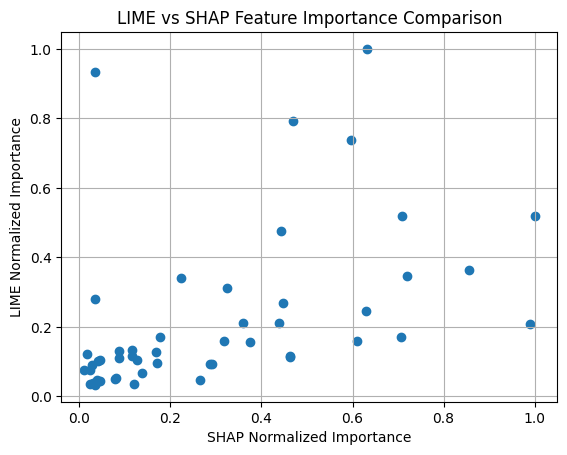

In [29]:

plt.figure()
plt.scatter(
    comparison_df["SHAP_Norm"],
    comparison_df["LIME_Norm"]
)
plt.xlabel("SHAP Normalized Importance")
plt.ylabel("LIME Normalized Importance")
plt.title("LIME vs SHAP Feature Importance Comparison")
plt.grid(True)
plt.show()


In [30]:
print(" MULTI-CLASS SHAP ANALYSIS FOR ATTACK TYPE CLASSIFICATION")
print("=" * 70)

try:
    # Create TreeExplainer for multi-class Random Forest
    multiclass_explainer = shap.TreeExplainer(multiclass_model)
    
    # Calculate SHAP values for test set
    multiclass_shap_values = multiclass_explainer.shap_values(X_test_filtered)
    
    print(f" SHAP values computed successfully")
    print(f"   Shape: {multiclass_shap_values.shape if not isinstance(multiclass_shap_values, list) else [v.shape for v in multiclass_shap_values]}")
    print(f"   Attack types: {label_encoder.classes_}")
    print(f"   Expected values: {multiclass_explainer.expected_value}")
    
    # Handle different SHAP output formats
    if isinstance(multiclass_shap_values, list):
        # Convert list to 3D array: (n_classes, n_samples, n_features) -> (n_samples, n_features, n_classes)
        multiclass_shap_values = np.array(multiclass_shap_values).transpose(1, 2, 0)
        n_classes = multiclass_shap_values.shape[2]
        print(f"   Format: Converted list to 3D array with {n_classes} classes")
        print(f"   New shape: {multiclass_shap_values.shape}")
    else:
        # Format: Single 3D array
        if multiclass_shap_values.ndim == 3:
            n_classes = multiclass_shap_values.shape[2]
            print(f"   Format: 3D array with {n_classes} classes")
        else:
            n_classes = len(label_encoder.classes_)
            print(f"   Format: 2D array")
    
    print(f"\n CREATING MULTI-CLASS VISUALIZATIONS...")
    
except Exception as e:
    print(f" Error computing multi-class SHAP values: {e}")
    import traceback
    print(traceback.format_exc())

 MULTI-CLASS SHAP ANALYSIS FOR ATTACK TYPE CLASSIFICATION
 SHAP values computed successfully
   Shape: (226871, 50, 10)
   Attack types: ['BENIGN' 'Bot' 'Brute Force' 'DDoS' 'DoS' 'Infiltration' 'Port Scan'
 'Web AttackSql Injection' 'Web AttackXSS' 'web attack brute force']
   Expected values: [0.09951509 0.09981377 0.09956463 0.09950139 0.09942067 0.10788673
 0.09954563 0.09570893 0.09830431 0.10073885]
   Format: 3D array with 10 classes

 CREATING MULTI-CLASS VISUALIZATIONS...


## 12. Multi-Class SHAP Analysis
Advanced SHAP analysis for understanding attack type classification decisions.


GLOBAL FEATURE IMPORTANCE ACROSS ALL ATTACK TYPES...


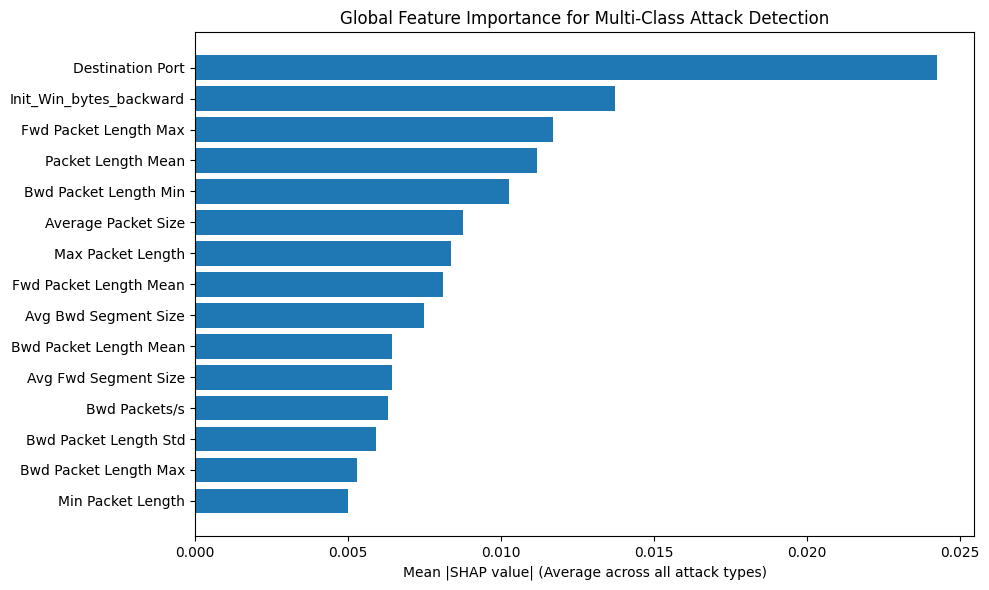


 TOP 15 MOST IMPORTANT FEATURES GLOBALLY:
    1. Destination Port                         : 0.0242
    2. Init_Win_bytes_backward                  : 0.0137
    3. Fwd Packet Length Max                    : 0.0117
    4. Packet Length Mean                       : 0.0112
    5. Bwd Packet Length Min                    : 0.0103
    6. Average Packet Size                      : 0.0088
    7. Max Packet Length                        : 0.0084
    8. Fwd Packet Length Mean                   : 0.0081
    9. Avg Bwd Segment Size                     : 0.0075
   10. Bwd Packet Length Mean                   : 0.0064
   11. Avg Fwd Segment Size                     : 0.0064
   12. Bwd Packets/s                            : 0.0063
   13. Bwd Packet Length Std                    : 0.0059
   14. Bwd Packet Length Max                    : 0.0053
   15. Min Packet Length                        : 0.0050


In [31]:
print("\nGLOBAL FEATURE IMPORTANCE ACROSS ALL ATTACK TYPES...")

try:
    # Compute mean absolute SHAP values across all classes
    if isinstance(multiclass_shap_values, list):
        # Average across all classes
        global_importance = np.mean([np.abs(sv).mean(axis=0) for sv in multiclass_shap_values], axis=0)
    elif multiclass_shap_values.ndim == 3:
        # Average across samples and classes
        global_importance = np.abs(multiclass_shap_values).mean(axis=(0, 2))
    else:
        global_importance = np.abs(multiclass_shap_values).mean(axis=0)
    
    # Create bar plot
    top_k = 15
    top_indices = np.argsort(global_importance)[-top_k:]
    
    plt.figure(figsize=(10, 6))
    plt.barh(range(top_k), global_importance[top_indices])
    plt.yticks(range(top_k), X_test_filtered.columns[top_indices])
    plt.xlabel("Mean |SHAP value| (Average across all attack types)")
    plt.title("Global Feature Importance for Multi-Class Attack Detection")
    plt.tight_layout()
    plt.show()
    
    # Print top features
    print(f"\n TOP {top_k} MOST IMPORTANT FEATURES GLOBALLY:")
    for i, idx in enumerate(top_indices[::-1]):
        print(f"   {i+1:2d}. {X_test_filtered.columns[idx]:40s} : {global_importance[idx]:.4f}")
    
except Exception as e:
    print(f" Error creating global importance plot: {e}")
    import traceback
    print(traceback.format_exc())

In [32]:
# ===== 11.3: MULTI-CLASS DECISION PLOT (CLASS COMPARISON) =====
print("\n DECISION PLOT: HOW FEATURES PUSH PREDICTION TOWARD EACH CLASS...")

try:
    # Select a sample that was correctly classified
    sample_idx = 0
    
    # Find a sample with confident multi-class prediction
    for i in range(len(X_test_filtered)):
        proba = multiclass_model.predict_proba(X_test_filtered.iloc[i:i+1])[0]
        if np.max(proba) > 0.6:  # Find confident prediction
            sample_idx = i
            break
    
    print(f"\n   Analyzing sample {sample_idx + 1}")
    print(f"   Actual: {attack_types_test_filtered.iloc[sample_idx]}")
    pred_class = multiclass_model.predict(X_test_filtered.iloc[sample_idx:sample_idx+1])[0]
    print(f"   Predicted: {label_encoder.inverse_transform([pred_class])[0]}")
    
    # Get SHAP values for this sample across all classes
    if isinstance(multiclass_shap_values, list):
        sample_shap_all_classes = [sv[sample_idx] for sv in multiclass_shap_values]
    elif multiclass_shap_values.ndim == 3:
        sample_shap_all_classes = [multiclass_shap_values[sample_idx, :, i] for i in range(multiclass_shap_values.shape[2])]
    else:
        sample_shap_all_classes = [multiclass_shap_values[sample_idx]]
    
    # Create decision plot showing all classes
    if isinstance(multiclass_explainer.expected_value, (list, np.ndarray)):
        expected_values = multiclass_explainer.expected_value
    else:
        expected_values = [multiclass_explainer.expected_value] * len(label_encoder.classes_)
    
    plt.figure(figsize=(12, 8))
    shap.decision_plot(
        expected_values,
        sample_shap_all_classes,
        X_test_filtered.iloc[sample_idx],
        feature_names=X_test_filtered.columns.tolist(),
        legend_labels=label_encoder.classes_.tolist(),
        legend_location='lower right',
        show=False
    )
    plt.title(f"Multi-Class Decision Plot - Sample {sample_idx + 1}")
    plt.tight_layout()
    plt.show()
    
    print("\n    INTERPRETATION:")
    print("   - Each line represents one attack class")
    print("   - Features push the prediction up/down for each class")
    print("   - Final position determines the predicted class")
    
except Exception as e:
    print(f"Error creating decision plot: {e}")
    import traceback
    print(traceback.format_exc())


 DECISION PLOT: HOW FEATURES PUSH PREDICTION TOWARD EACH CLASS...

   Analyzing sample 1
   Actual: BENIGN
   Predicted: BENIGN
Error creating decision plot: Looks like multi output. Try base_value[i] and shap_values[i], or use shap.multioutput_decision_plot().
Traceback (most recent call last):
  File "C:\Users\sures\AppData\Local\Temp\ipykernel_19732\1771368144.py", line 35, in <module>
    shap.decision_plot(
    ~~~~~~~~~~~~~~~~~~^
        expected_values,
        ^^^^^^^^^^^^^^^^
    ...<5 lines>...
        show=False
        ^^^^^^^^^^
    )
    ^
  File "c:\Users\sures\AppData\Local\Programs\Python\Python313\Lib\site-packages\shap\plots\_decision.py", line 360, in decision
    raise TypeError(
        "Looks like multi output. Try base_value[i] and shap_values[i], or use shap.multioutput_decision_plot()."
    )
TypeError: Looks like multi output. Try base_value[i] and shap_values[i], or use shap.multioutput_decision_plot().



In [33]:
print(" MULTI-CLASS LIME ANALYSIS FOR ATTACK TYPE CLASSIFICATION")
print("=" * 70)

try:
    # Create LIME explainer for multi-class classification
    multiclass_lime_explainer = lime.lime_tabular.LimeTabularExplainer(
        training_data=X_train_filtered.values,
        feature_names=X_train_filtered.columns.tolist(),
        class_names=label_encoder.classes_.tolist(),
        mode='classification',
        discretize_continuous=True,
        random_state=42
    )
    
    print(" Multi-class LIME explainer created successfully")
    print(f"   Attack types: {label_encoder.classes_.tolist()}")
    print(f"   Number of features: {len(X_train_filtered.columns)}")
    
    # Select diverse samples to explain
    n_samples_to_explain = min(5, len(X_test_filtered))
    
    # Try to get one sample from each attack type
    samples_to_explain = []
    for attack_type in label_encoder.classes_[:n_samples_to_explain]:
        matching_indices = attack_types_test_filtered[attack_types_test_filtered == attack_type].index
        if len(matching_indices) > 0:
            # Get the position in X_test_filtered
            sample_position = X_test_filtered.index.get_loc(matching_indices[0])
            samples_to_explain.append((sample_position, attack_type))
    
    print(f"\nSelected {len(samples_to_explain)} diverse samples for explanation")
    
    # Store explanations and actually generate them
    multiclass_lime_explanations = []
    
    # Generate explanations
    for sample_pos, attack_type in samples_to_explain:
        try:
            explanation = multiclass_lime_explainer.explain_instance(
                X_test_filtered.iloc[sample_pos].values,
                multiclass_model.predict_proba,
                num_features=10
            )
            multiclass_lime_explanations.append(explanation)
            print(f"Generated explanation for {attack_type}")
        except Exception as e:
            print(f"Error explaining {attack_type}: {e}")
    
    print(f"Generated {len(multiclass_lime_explanations)} LIME explanations")
    
except Exception as e:
    print(f" Error creating multi-class LIME explainer: {e}")
    import traceback
    print(traceback.format_exc())

 MULTI-CLASS LIME ANALYSIS FOR ATTACK TYPE CLASSIFICATION
 Multi-class LIME explainer created successfully
   Attack types: ['BENIGN', 'Bot', 'Brute Force', 'DDoS', 'DoS', 'Infiltration', 'Port Scan', 'Web AttackSql Injection', 'Web AttackXSS', 'web attack brute force']
   Number of features: 50

Selected 5 diverse samples for explanation
Generated explanation for BENIGN
Generated explanation for Bot
Generated explanation for Brute Force
Generated explanation for DDoS
Generated explanation for DoS
Generated 5 LIME explanations


## 13. Multi-Class LIME Analysis
Local explanations for multi-class attack type predictions using LIME.

In [34]:
print("\n AGGREGATE LIME INSIGHTS ACROSS ALL EXPLAINED SAMPLES")
print("=" * 70)

try:
    # Collect all feature importances across explanations
    feature_importance_by_class = {attack: [] for attack in label_encoder.classes_}
    
    for explanation in multiclass_lime_explanations:
        for class_idx in explanation.available_labels():
            attack_type = label_encoder.classes_[class_idx]
            features_weights = explanation.as_list(label=class_idx)
            feature_importance_by_class[attack_type].extend(features_weights)
    
    # Find most frequently important features for each attack type
    print("\n MOST DISCRIMINATIVE FEATURES FOR EACH ATTACK TYPE:")
    print("   (Based on LIME local explanations)")
    
    for attack_type in label_encoder.classes_:
        if feature_importance_by_class[attack_type]:
            # Count feature mentions and average weights
            feature_mentions = {}
            for feature_str, weight in feature_importance_by_class[attack_type]:
                # Extract base feature name
                base_feature = feature_str.split('<=')[0].split('>')[0].strip()
                if base_feature not in feature_mentions:
                    feature_mentions[base_feature] = []
                feature_mentions[base_feature].append(weight)
            
            # Calculate average absolute importance
            avg_importance = {feat: np.mean(np.abs(weights)) 
                            for feat, weights in feature_mentions.items()}
            
            # Get top 5 features
            top_features = sorted(avg_importance.items(), 
                                key=lambda x: x[1], reverse=True)[:5]
            
            print(f"\n   {attack_type}:")
            for i, (feature, importance) in enumerate(top_features, 1):
                print(f"      {i}. {feature[:35]:35s} (Avg |weight|: {importance:.4f})")
    
    print("\nAggregate LIME analysis completed")
    
except Exception as e:
    print(f" Error in aggregate analysis: {e}")
    import traceback
    print(traceback.format_exc())


 AGGREGATE LIME INSIGHTS ACROSS ALL EXPLAINED SAMPLES

 MOST DISCRIMINATIVE FEATURES FOR EACH ATTACK TYPE:
   (Based on LIME local explanations)

   Bot:
      1. Destination Port                    (Avg |weight|: 0.0329)
      2. Init_Win_bytes_backward             (Avg |weight|: 0.0174)
      3. 0.00 < Destination Port             (Avg |weight|: 0.0160)
      4. Bwd Packet Length Min               (Avg |weight|: 0.0095)
      5. Flow IAT Max                        (Avg |weight|: 0.0086)

Aggregate LIME analysis completed


SHAP analysis completed successfully.


<Figure size 1200x800 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

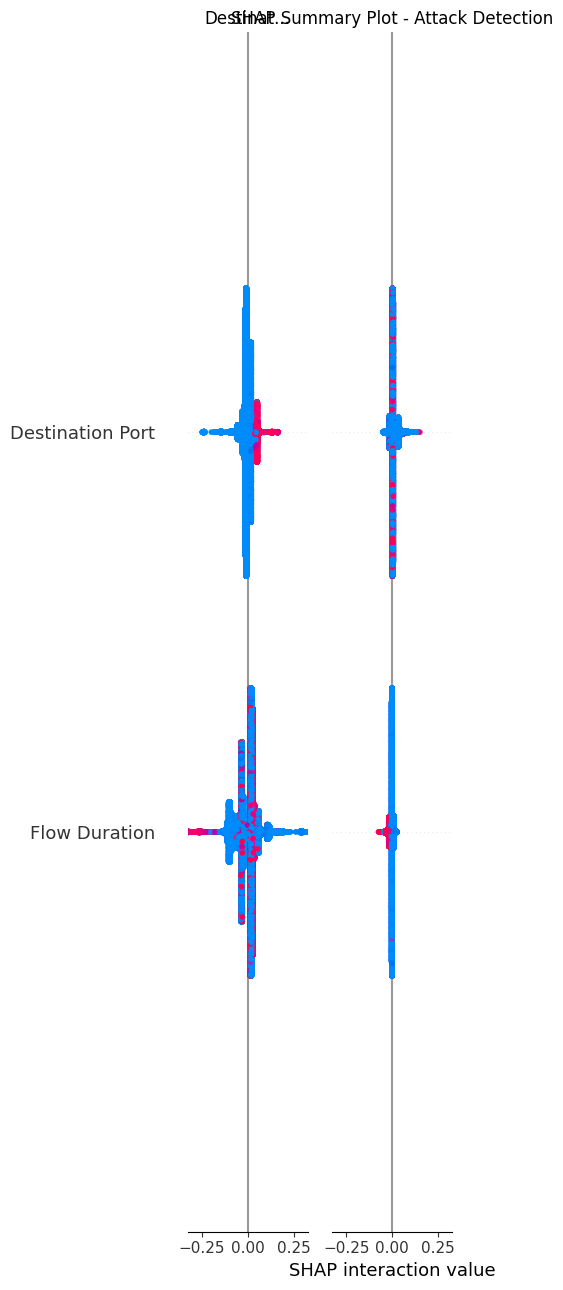

<Figure size 1000x600 with 0 Axes>

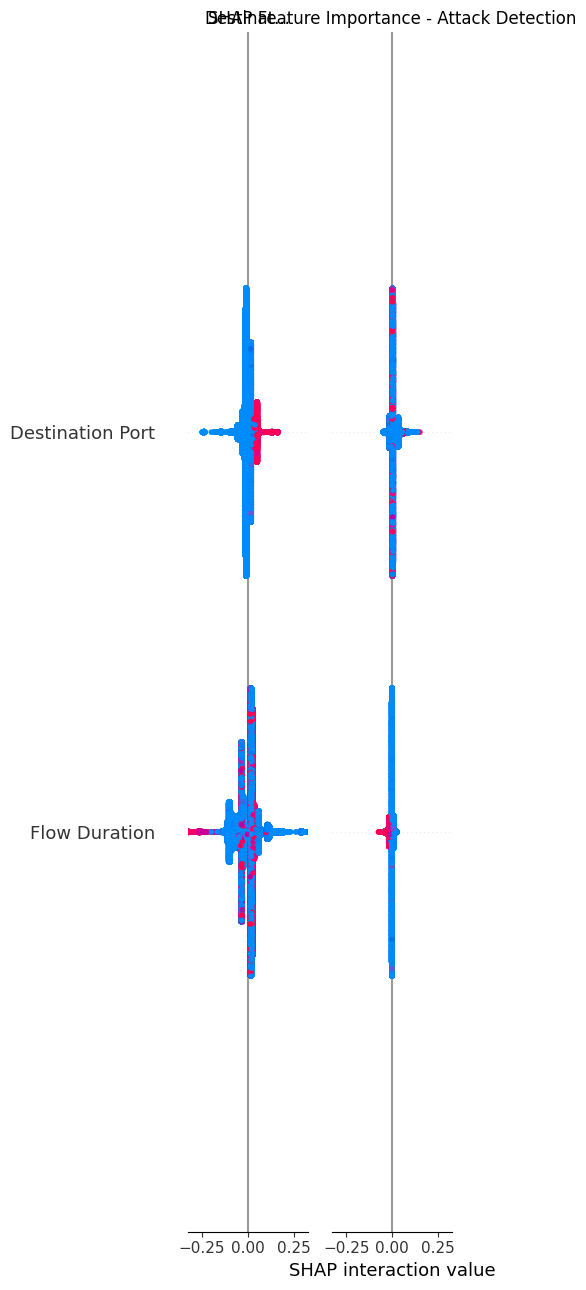

In [35]:
# Corrected SHAP Implementation for Binary Classification
import warnings
warnings.filterwarnings('ignore')

try:
    # Create SHAP explainer for binary classification
    binary_explainer = shap.TreeExplainer(ids_model)
    binary_shap_values = binary_explainer.shap_values(X_test)
    
    # Handle SHAP values properly
    if isinstance(binary_shap_values, list) and len(binary_shap_values) >= 2:
        shap_values_attack = binary_shap_values[1]  # Attack class
        expected_value_attack = binary_explainer.expected_value[1]
    else:
        shap_values_attack = binary_shap_values[0] if isinstance(binary_shap_values, list) else binary_shap_values
        expected_value_attack = binary_explainer.expected_value[0] if isinstance(binary_explainer.expected_value, (list, np.ndarray)) else binary_explainer.expected_value
    
    print("SHAP analysis completed successfully.")
    
    # Generate SHAP summary plot
    plt.figure(figsize=(10, 6))
    shap.summary_plot(
        shap_values_attack,
        X_test,
        max_display=15,
        show=False
    )
    plt.title("SHAP Summary Plot - Attack Detection")
    plt.tight_layout()
    plt.show()
    
    # Generate feature importance bar plot
    plt.figure(figsize=(10, 6))
    shap.summary_plot(
        shap_values_attack,
        X_test,
        plot_type="bar",
        max_display=15,
        show=False
    )
    plt.title("SHAP Feature Importance - Attack Detection")
    plt.tight_layout()
    plt.show()
    
except Exception as e:
    print(f"SHAP analysis failed: {e}")
    
    # Fallback: Random Forest feature importance
    feature_importance = pd.DataFrame({
        'feature': X_test.columns,
        'importance': ids_model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    plt.figure(figsize=(10, 6))
    top_features = feature_importance.head(15)
    plt.barh(range(len(top_features)), top_features['importance'][::-1])
    plt.yticks(range(len(top_features)), top_features['feature'][::-1])
    plt.xlabel("Feature Importance")
    plt.title("Random Forest Feature Importance")
    plt.tight_layout()
    plt.show()
    
    print("Top 10 features:")
    for i, (_, row) in enumerate(feature_importance.head(10).iterrows()):
        print(f"   {i+1:2d}. {row['feature'][:40]:40s} : {row['importance']:.4f}")

## 14. Model Verification and Final Analysis
Final verification of models and comprehensive feature-attack relationship analysis.

In [36]:
# Multi-class Classifier Verification
try:
    if 'multiclass_model' in locals() and 'label_encoder' in locals():
        print("Multi-class model verified.")
        print(f"Attack types: {label_encoder.classes_}")
        
        # Test on 3 samples only
        if len(X_test_filtered) > 0:
            print(f"\nTesting on {min(3, len(X_test_filtered))} samples:")
            
            for i in range(min(3, len(X_test_filtered))):
                sample = X_test_filtered.iloc[i:i+1]
                actual_type = attack_types_test_filtered.iloc[i]
                
                pred_class = multiclass_model.predict(sample)[0]
                pred_type = label_encoder.inverse_transform([pred_class])[0]
                
                match_status = "Correct" if actual_type == pred_type else "Incorrect"
                print(f"   Sample {i+1}: Actual={actual_type}, Predicted={pred_type} ({match_status})")
        else:
            print("No samples available for multi-class testing.")
    
    else:
        print("Multi-class model not found.")
        
        if 'attack_types_train_filtered' in locals() and 'y_train_multiclass' in locals():
            multiclass_model = RandomForestClassifier(
                n_estimators=100,
                random_state=42,
                max_depth=8,
                min_samples_split=15,
                min_samples_leaf=5,
                class_weight='balanced'
            )
            
            print("Training new multi-class model...")
            multiclass_model.fit(X_train_filtered, y_train_multiclass)
            print("Multi-class model trained successfully.")
        else:
            print("Required data not found for multi-class training.")
    
    print("Multi-class verification completed.")
    
except Exception as e:
    print(f"Multi-class verification failed: {e}")

Multi-class model verified.
Attack types: ['BENIGN' 'Bot' 'Brute Force' 'DDoS' 'DoS' 'Infiltration' 'Port Scan'
 'Web AttackSql Injection' 'Web AttackXSS' 'web attack brute force']

Testing on 3 samples:
   Sample 1: Actual=BENIGN, Predicted=BENIGN (Correct)
   Sample 2: Actual=BENIGN, Predicted=BENIGN (Correct)
   Sample 3: Actual=DoS, Predicted=DoS (Correct)
Multi-class verification completed.


In [37]:
# Corrected Prediction Function
def corrected_predict_attack_type(sample_features, show_details=True):
   
    try:
        # Ensure sample_features is 2D for prediction
        if hasattr(sample_features, 'values'):
            sample_2d = sample_features.values.reshape(1, -1)
        else:
            sample_2d = np.array(sample_features).reshape(1, -1)
        
        # Binary prediction (Attack vs Normal)
        binary_pred = ids_model.predict(sample_2d)[0]
        binary_proba = ids_model.predict_proba(sample_2d)[0]
        
        results = {
            'is_attack': binary_pred == 1,
            'attack_confidence': binary_proba[1],
            'normal_confidence': binary_proba[0],
            'binary_prediction': 'Attack' if binary_pred == 1 else 'Normal'
        }
        
        # Multi-class prediction (only if detected as attack and models exist)
        if binary_pred == 1 and 'multiclass_model' in globals() and 'label_encoder' in globals():
            try:
                # Check if sample is compatible with multi-class model
                if sample_2d.shape[1] == X_train_filtered.shape[1]:
                    multiclass_pred = multiclass_model.predict(sample_2d)[0]
                    attack_type_pred = label_encoder.inverse_transform([multiclass_pred])[0]
                    multiclass_proba = multiclass_model.predict_proba(sample_2d)[0]
                    
                    # Get top 3 predictions
                    top_3_indices = np.argsort(multiclass_proba)[-3:][::-1]
                    top_predictions = []
                    for idx in top_3_indices:
                        attack_name = label_encoder.classes_[idx]
                        confidence = multiclass_proba[idx]
                        top_predictions.append((attack_name, confidence))
                    
                    results.update({
                        'predicted_attack_type': attack_type_pred,
                        'top_3_predictions': top_predictions,
                        'multiclass_available': True
                    })
                else:
                    results.update({
                        'predicted_attack_type': 'Feature dimension mismatch',
                        'top_3_predictions': [('Binary Attack', binary_proba[1])],
                        'multiclass_available': False
                    })
                    
            except Exception as e:
                results.update({
                    'predicted_attack_type': f'Multi-class error: {str(e)}',
                    'top_3_predictions': [('Binary Attack', binary_proba[1])],
                    'multiclass_available': False
                })
        else:
            # Not an attack or multi-class not available
            if binary_pred == 0:
                results.update({
                    'predicted_attack_type': 'Normal (not an attack)',
                    'top_3_predictions': [('Normal', binary_proba[0])],
                    'multiclass_available': False
                })
            else:
                results.update({
                    'predicted_attack_type': 'Attack (multi-class not available)',
                    'top_3_predictions': [('Generic Attack', binary_proba[1])],
                    'multiclass_available': False
                })
        
        if show_details:
            print(f" CORRECTED ATTACK TYPE ANALYSIS:")
            print(f"   Binary Classification: {results['binary_prediction']}")
            print(f"   Confidence: Normal={results['normal_confidence']:.3f}, Attack={results['attack_confidence']:.3f}")
            print(f"   Attack Type: {results['predicted_attack_type']}")
            print(f"   Multi-class Available: {results['multiclass_available']}")
            print(f"   Top Predictions:")
            for i, (name, conf) in enumerate(results['top_3_predictions']):
                print(f"      {i+1}. {name}: {conf:.3f}")
        
        return results
        
    except Exception as e:
        error_result = {
            'error': str(e),
            'is_attack': None,
            'attack_confidence': None,
            'predicted_attack_type': 'Prediction failed'
        }
        if show_details:
            print(f" Error in prediction: {e}")
        return error_result

# ===== TEST THE CORRECTED FUNCTION =====
print("\n TESTING CORRECTED PREDICTION FUNCTION:")
print("=" * 60)

# Test with first 3 samples
for i in range(min(3, len(X_test))):
    print(f"\n{'-' * 40}")
    print(f" SAMPLE {i+1} TEST:")
    print(f"{'-' * 40}")
    
    sample = X_test.iloc[i]
    actual_label = y_test.iloc[i]
    actual_attack_type = attack_types_test.iloc[i]
    
    print(f"Actual: {actual_attack_type} ({'Attack' if actual_label == 1 else 'Normal'})")
    
    # Test corrected function
    result = corrected_predict_attack_type(sample)
    
    # Check accuracy
    binary_match = (result.get('is_attack', False) and actual_label == 1) or (not result.get('is_attack', True) and actual_label == 0)
    print(f"Binary Accuracy: {'Correct' if binary_match else 'Incorrect'}")
    
    if result.get('multiclass_available', False) and actual_label == 1:
        multiclass_match = result.get('predicted_attack_type') == actual_attack_type
        print(f"Multi-class Accuracy: {'Correct' if multiclass_match else 'Incorrect'}")

print("\n Corrected prediction function testing completed!")


 TESTING CORRECTED PREDICTION FUNCTION:

----------------------------------------
 SAMPLE 1 TEST:
----------------------------------------
Actual: BENIGN (Normal)
 CORRECTED ATTACK TYPE ANALYSIS:
   Binary Classification: Normal
   Confidence: Normal=0.999, Attack=0.001
   Attack Type: Normal (not an attack)
   Multi-class Available: False
   Top Predictions:
      1. Normal: 0.999
Binary Accuracy: Correct

----------------------------------------
 SAMPLE 2 TEST:
----------------------------------------
Actual: BENIGN (Normal)
 CORRECTED ATTACK TYPE ANALYSIS:
   Binary Classification: Normal
   Confidence: Normal=0.992, Attack=0.008
   Attack Type: Normal (not an attack)
   Multi-class Available: False
   Top Predictions:
      1. Normal: 0.992
Binary Accuracy: Correct

----------------------------------------
 SAMPLE 3 TEST:
----------------------------------------
Actual: DoS (Attack)
 CORRECTED ATTACK TYPE ANALYSIS:
   Binary Classification: Normal
   Confidence: Normal=0.506, Atta

In [38]:
# FEATURE-ATTACK RELATIONSHIP ANALYSIS
# Identifies which features drive each attack type and their threshold ranges

from scipy.stats import pearsonr

# Get attack type classes
attack_classes = label_encoder.classes_

# Prepare results storage
feature_attack_table = []

# Check if multiclass_shap_values is available and in correct format
if 'multiclass_shap_values' in locals() and isinstance(multiclass_shap_values, np.ndarray) and multiclass_shap_values.ndim == 3:
    print("Using SHAP values for feature-attack analysis")
    
    # For each attack type, find top features using multi-class SHAP values
    for class_idx, attack_name in enumerate(attack_classes):
        if attack_name == 'BENIGN':
            continue
        
        # Get SHAP values for this class
        class_shap = multiclass_shap_values[:, :, class_idx]
        
        # Mean absolute SHAP importance per feature for this class
        feature_importance_class = np.abs(class_shap).mean(axis=0)
        
        # Get top 3 features for this attack
        top_feature_indices = np.argsort(feature_importance_class)[-3:][::-1]
        
        for rank, feat_idx in enumerate(top_feature_indices, 1):
            feat_name = X_test_filtered.columns[feat_idx]
            importance = feature_importance_class[feat_idx]
            
            # Get samples predicted as this attack type
            pred_labels = multiclass_model.predict(X_test_filtered)
            attack_mask = pred_labels == class_idx
            
            if attack_mask.sum() > 10:
                # Feature values for attack samples
                attack_values = X_test_filtered.iloc[attack_mask, feat_idx]
                # Feature values for benign samples
                benign_mask = pred_labels == 0
                benign_values = X_test_filtered.iloc[benign_mask, feat_idx]
                
                # Calculate threshold as mean of attack samples
                attack_mean = attack_values.mean()
                attack_std = attack_values.std()
                benign_mean = benign_values.mean() if benign_mask.sum() > 0 else 0
                
                # Determine direction
                if attack_mean > benign_mean:
                    direction = "HIGH"
                    threshold = f"> {attack_mean - attack_std:.4f}"
                else:
                    direction = "LOW"
                    threshold = f"< {attack_mean + attack_std:.4f}"
            else:
                direction = "N/A"
                threshold = "Insufficient samples"
            
            feature_attack_table.append({
                'Attack_Type': attack_name,
                'Rank': rank,
                'Feature': feat_name,
                'SHAP_Importance': round(importance, 4),
                'Direction': direction,
                'Threshold_Range': threshold
            })

else:
    print("SHAP values not available. Using Random Forest feature importance instead.")
    
    # Use Random Forest feature importance as fallback
    feature_importance_global = multiclass_model.feature_importances_
    
    for class_idx, attack_name in enumerate(attack_classes):
        if attack_name == 'BENIGN':
            continue
            
        # Get top 3 features based on global importance
        top_feature_indices = np.argsort(feature_importance_global)[-3:][::-1]
        
        for rank, feat_idx in enumerate(top_feature_indices, 1):
            feat_name = X_test_filtered.columns[feat_idx]
            importance = feature_importance_global[feat_idx]
            
            feature_attack_table.append({
                'Attack_Type': attack_name,
                'Rank': rank,
                'Feature': feat_name,
                'RF_Importance': round(importance, 4)
            })

# Create DataFrame and display
if feature_attack_table:
    results_df = pd.DataFrame(feature_attack_table)
    
    print("\nFEATURE-ATTACK RELATIONSHIP TABLE")
    print("="*90)
    
    if 'SHAP_Importance' in results_df.columns:
        print(f"{'Attack Type':<25} {'Rank':<5} {'Feature':<30} {'SHAP':<8} {'Direction':<10} {'Threshold':<15}")
        print("-"*90)
        for _, row in results_df.iterrows():
            print(f"{row['Attack_Type']:<25} {row['Rank']:<5} {row['Feature']:<30} {row['SHAP_Importance']:<8} {row.get('Direction', 'N/A'):<10} {row.get('Threshold_Range', 'N/A'):<15}")
    else:
        print(f"{'Attack Type':<25} {'Rank':<5} {'Feature':<30} {'RF Importance':<15}")
        print("-"*75)
        for _, row in results_df.iterrows():
            print(f"{row['Attack_Type']:<25} {row['Rank']:<5} {row['Feature']:<30} {row['RF_Importance']:<15}")
    
    print("="*90)
    print("")
    print("SUMMARY: Top Feature per Attack Type")
    print("-"*60)
    top_features = results_df[results_df['Rank'] == 1]
    for _, row in top_features.iterrows():
        if 'SHAP_Importance' in row:
            print(f"{row['Attack_Type']}: {row['Feature']} ({row.get('Direction', 'N/A')} values {row.get('Threshold_Range', 'N/A')})")
        else:
            print(f"{row['Attack_Type']}: {row['Feature']} (RF Importance: {row['RF_Importance']})")
else:
    print("No feature-attack relationships could be analyzed.")

Using SHAP values for feature-attack analysis

FEATURE-ATTACK RELATIONSHIP TABLE
Attack Type               Rank  Feature                        SHAP     Direction  Threshold      
------------------------------------------------------------------------------------------
Bot                       1     Destination Port               0.03     HIGH       > 0.3163       
Bot                       2     Init_Win_bytes_backward        0.0201   HIGH       > -0.1454      
Bot                       3     Bwd Packet Length Min          0.007    LOW        < 0.0023       
Brute Force               1     Destination Port               0.0583   LOW        < 0.0003       
Brute Force               2     Bwd Packet Length Min          0.0081   LOW        < 0.0000       
Brute Force               3     Fwd Packet Length Max          0.0072   LOW        < 0.0197       
DDoS                      1     Fwd Packet Length Max          0.0202   LOW        < 0.0009       
DDoS                      2     Fwd 

In [39]:
# LIME Explanation for One Attack Sample

# Find one sample classified as an attack (not BENIGN)
attack_sample_idx = None
for i in range(len(X_test_filtered)):
    pred = multiclass_model.predict(X_test_filtered.iloc[i:i+1])[0]
    pred_label = label_encoder.inverse_transform([pred])[0]
    if pred_label != 'BENIGN':
        attack_sample_idx = i
        break

if attack_sample_idx is not None:
    sample_data = X_test_filtered.iloc[attack_sample_idx]
    actual_type = attack_types_test_filtered.iloc[attack_sample_idx]
    pred_class = multiclass_model.predict(sample_data.values.reshape(1, -1))[0]
    predicted_type = label_encoder.inverse_transform([pred_class])[0]
    
    # Create LIME explanation
    single_explainer = lime.lime_tabular.LimeTabularExplainer(
        training_data=X_train_filtered.values,
        feature_names=X_train_filtered.columns.tolist(),
        class_names=label_encoder.classes_.tolist(),
        mode='classification',
        discretize_continuous=True,
        random_state=42
    )
    
    exp = single_explainer.explain_instance(
        sample_data.values,
        multiclass_model.predict_proba,
        num_features=10,
        top_labels=1
    )
    
    feature_conditions = exp.as_list(label=pred_class)
    
    print("LIME EXPLANATION FOR ONE ATTACK SAMPLE")
    print("=" * 70)
    print("Sample Index:", attack_sample_idx)
    print("Actual Attack Type:", actual_type)
    print("Predicted Attack Type:", predicted_type)
    print("Prediction Confidence:", round(multiclass_model.predict_proba(sample_data.values.reshape(1, -1))[0][pred_class], 3))
    print("")
    print("Features Contributing to This Prediction:")
    print("-" * 70)
    print("{:<50} {:>10}".format("Feature Condition", "Weight"))
    print("-" * 70)
    
    for condition, weight in feature_conditions:
        sign = "+" if weight > 0 else "-"
        print("{:<50} {}{}".format(condition, sign, round(abs(weight), 4)))
    
    print("-" * 70)
    print("")
    print("Interpretation:")
    print("Positive weights push toward this attack type.")
    print("Negative weights push away from this attack type.")
else:
    print("No attack samples found in test set.")

LIME EXPLANATION FOR ONE ATTACK SAMPLE
Sample Index: 2
Actual Attack Type: DoS
Predicted Attack Type: DoS
Prediction Confidence: 0.616

Features Contributing to This Prediction:
----------------------------------------------------------------------
Feature Condition                                      Weight
----------------------------------------------------------------------
Bwd Packet Length Min <= 0.00                      +0.0208
0.00 < Destination Port <= 0.00                    +0.0199
Bwd Packet Length Std <= 0.00                      -0.0156
Min Packet Length <= 0.00                          +0.015
Average Packet Size <= 0.00                        +0.0144
Bwd Packet Length Mean <= 0.00                     +0.0106
URG Flag Count <= 0.00                             -0.0086
Bwd Packet Length Max <= 0.00                      +0.0076
Packet Length Mean <= 0.00                         +0.0063
Bwd IAT Std <= 0.00                                +0.0055
-----------------------------

In [41]:
# MODEL VALIDATION AND ERROR CHECKING
print("\n" + "="*60)
print("MODEL VALIDATION AND ERROR CHECKING")
print("="*60)

# Check if all required variables exist
required_vars = ['ids_model', 'multiclass_model', 'X_test', 'y_test', 'label_encoder']
missing_vars = []
for var in required_vars:
    if var not in globals():
        missing_vars.append(var)

if missing_vars:
    print(f"Warning: Missing variables: {missing_vars}")
else:
    print("All required models and data are available")

# Check data shapes
print(f"\nData Shapes:")
print(f"  Training data: {X_train.shape}")
print(f"  Test data: {X_test.shape}")
print(f"  Multi-class filtered test: {X_test_filtered.shape if 'X_test_filtered' in globals() else 'Not available'}")

# Check model performance
if 'accuracy' in globals():
    print(f"\nBinary Classification Performance:")
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall: {recall:.4f}")
    print(f"  F1-Score: {f1:.4f}")
    
   

# Validate multi-class model
if 'multiclass_accuracy' in globals():
    print(f"\nMulti-class Performance: {multiclass_accuracy:.4f}")

# Check data balance
print(f"\nData Balance:")
print(f"  Training - Normal: {sum(y_train == 0)}, Attack: {sum(y_train == 1)}")
print(f"  Test - Normal: {sum(y_test == 0)}, Attack: {sum(y_test == 1)}")

# Check SHAP analysis
if 'shap_values_attack' in globals():
    print(f"\nSHAP Analysis:")
    print(f"  Binary SHAP values available: {shap_values_attack.shape}")
else:
    print(f"\nSHAP analysis not completed")

if 'multiclass_shap_values' in globals():
    print(f"  Multi-class SHAP values available: {multiclass_shap_values.shape}")
else:
    print(f"  Multi-class SHAP analysis not completed")

# Check LIME analysis
if 'multiclass_lime_explanations' in globals():
    print(f"\nLIME Analysis:")
    print(f"  LIME explanations generated: {len(multiclass_lime_explanations)} samples")
else:
    print(f"\nLIME analysis not completed")

print("="*60)
print("VALIDATION COMPLETE")
print("="*60)


MODEL VALIDATION AND ERROR CHECKING
All required models and data are available

Data Shapes:
  Training data: (529367, 50)
  Test data: (226872, 50)
  Multi-class filtered test: (226871, 50)

Binary Classification Performance:
  Accuracy: 0.9945
  Precision: 0.9971
  Recall: 0.9705
  F1-Score: 0.9836

Multi-class Performance: 0.9612

Data Balance:
  Training - Normal: 439962, Attack: 89405
  Test - Normal: 188555, Attack: 38317

SHAP Analysis:
  Binary SHAP values available: (226872, 50, 2)
  Multi-class SHAP values available: (226871, 50, 10)

LIME Analysis:
  LIME explanations generated: 5 samples
VALIDATION COMPLETE
